# Does the power-law extrapolation hold up past 14.9um?

`michelson-extrapolation.ipynb` fit a power law on Elf Owl's 12-14um continuum and
checked it against real Elf Owl flux on 14-14.9um -- the only place ground truth
exists, since the grid stops at 14.9um. That check showed the power law tracks the
continuum but misses molecular absorption features (wide swings at specific
wavelengths, worse for the Y grid).

F1550C actually needs 14.912-16.219um, which is *past* where Elf Owl can validate
anything. This notebook uses Sonora Bobcat as a stand-in ground truth instead: it's a
different brown-dwarf model grid, but one that actually has real coverage out to
17um and spans the same teff/logg range as both Elf Owl grids combined. So the same
fit-on-12-14um, predict-further-out method can be checked against *real* flux all
the way to 16.6um, instead of stopping at 14.9um.

Caveat: Bobcat isn't Elf Owl -- different chemistry/opacity treatment, no vertical
mixing (`log_kzz`) or C/O variation. This is a plausibility check on whether a
featureless power law is a reasonable model for a brown dwarf spectrum that far past
14.9um, not a direct substitute for validating Elf Owl itself.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import helpers.generate_planet_list as helpers
from species import SpeciesInit
from species.data.database import Database
from species.read.read_model import ReadModel

SpeciesInit()
db = Database()

/opt/homebrew/Caskroom/miniconda/base/envs/dwarfhunt/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


species

Version: 0.10.4
Working folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/michelson-repro

Configuration file: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/michelson-repro/species_config.ini
Database file: species_database.hdf5
Data folder: data

Configuration settings:
   - Database: species_database.hdf5
   - Data folder: data
   - Magnitude of Vega: 0.03

Multiprocessing: mpi4py not installed


## Retrieve the data
Only run this section if you don't have Sonora Bobcat downloaded. It covers teff
200-2400K, logg 3-5.5, feh -0.5/0/0.5, wavelength 0.61-17um -- teff/logg fully contains
Elf Owl's combined T (575-1200K) + Y (275-550K) range, and reaches almost 2.5um past
what F1550C needs. `wavel_range` is restricted at download the same way Elf Owl's was,
to avoid the ~69GB peak `add_model` hits with no range specified.

In [ ]:
db.add_model('sonora-bobcat', wavel_range=(0.61, 17.0), wavel_sampling=1000.0)

## Sanity check the grid, then sample planets across Elf Owl's combined range

Same missing-spectrum scan `generate_planet_list.py` uses for Elf Owl (it's generic --
reads whatever parameters the grid's own HDF5 attrs declare), just to confirm Bobcat
doesn't have Elf Owl's logg=3.0 gap before trusting `get_model` interpolation near the
edges of the sampled range.

In [2]:
params, axes, mask = helpers.scan_missing_grid_points('sonora-bobcat')
print(f"sonora-bobcat: {mask.sum()} / {mask.size} grid cells missing a spectrum")

sonora-bobcat: 0 / 1287 grid cells missing a spectrum


In [3]:
# teff/logg drawn uniformly across Elf Owl's combined T+Y range (275-1200K, logg 3-5.5).
# feh fixed at Bobcat's solar node (0.0) -- feh isn't what's under test here.
model = ReadModel('sonora-bobcat', wavel_range=(0.61, 17.0))

rng = np.random.default_rng(0)
n_samples = 200
teff = rng.uniform(275.0, 1200.0, n_samples)
logg = rng.uniform(3.0, 5.5, n_samples)

wl = None
flux = None

with helpers.skip_nearest_spec_check():
    for i in range(n_samples):
        box = model.get_model({'teff': float(teff[i]), 'logg': float(logg[i]), 'feh': 0.0})
        if flux is None:
            wl = box.wavelength
            flux = np.empty((n_samples, wl.size))
        flux[i] = box.flux

print(f"pulled {n_samples} interpolated Bobcat spectra, {wl.size} wavelength points ({wl.min():.2f}-{wl.max():.2f}um)")

pulled 200 interpolated Bobcat spectra, 3362 wavelength points (0.61-17.00um)


## Fit on 12-14um, check against real flux all the way to 16.6um

Same `fit_power_law`/`predict_power_law` used for the Elf Owl check -- they're generic,
not tied to Elf Owl's 5-parameter grid. The only difference is `test_range` now reaches
16.6um instead of stopping at 14.9um, since Bobcat actually has real flux out that far.

In [4]:
fit_range = (12.0, 14.0)
test_range = (14.0, 16.6)

slope, intercept = helpers.fit_power_law(wl, flux, fit_range)

test_mask = (wl >= test_range[0]) & (wl <= test_range[1])
wl_test = wl[test_mask]
actual = flux[:, test_mask]
predicted = helpers.predict_power_law(wl_test, slope, intercept)

result_bobcat = {
    "tag": "sonora-bobcat (proxy for Elf Owl past 14.9um)",
    "wl_test": wl_test,
    "residual": helpers.check_power_law(predicted, actual),
    "slope": slope,
    "intercept": intercept,
    "teff": teff,
}

print(f"median residual {np.nanmedian(result_bobcat['residual'])*100:+.1f}%, "
      f"16th-84th pct |residual| {np.nanpercentile(np.abs(result_bobcat['residual']), 16)*100:.1f}%-"
      f"{np.nanpercentile(np.abs(result_bobcat['residual']), 84)*100:.1f}%")

median residual +8.8%, 16th-84th pct |residual| 3.9%-52.3%


Text(15.55, 193.68072241633348, 'F1550C')

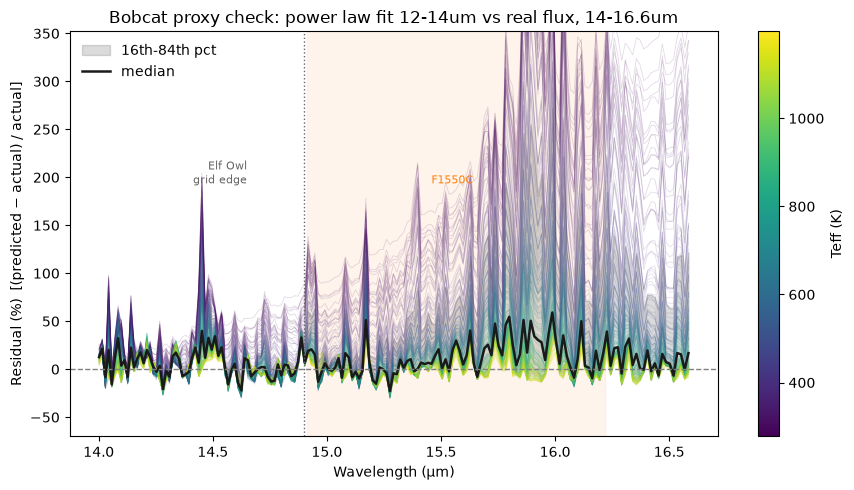

In [5]:
fig, ax = helpers.plot_extrapolation_residuals(
    result_bobcat,
    title="Bobcat proxy check: power law fit 12-14um vs real flux, 14-16.6um"
)

# Elf Owl's grid edge (where its own validation had to stop) and F1550C's actual
# coverage (14.912-16.219um), for direct comparison against the Elf Owl-only plots.
ax.axvline(14.9, color="0.4", linewidth=1, linestyle=":")
ax.axvspan(14.912, 16.219, color="tab:orange", alpha=0.08)
ax.text(14.65, ax.get_ylim()[1]*0.55, "Elf Owl\ngrid edge", fontsize=8, color="0.4", ha="right")
ax.text(15.55, ax.get_ylim()[1]*0.55, "F1550C", fontsize=8, color="tab:orange", ha="center")

## How does the error grow with distance past the grid edge?

Bin the residual by wavelength, using 14.9um (Elf Owl's grid edge) as the reference
point the earlier notebook was stuck at. The last bin is F1550C's actual coverage.

In [6]:
bins = [(14.0, 14.9), (14.9, 15.5), (15.5, 16.0), (16.0, 16.6), (14.912, 16.219)]
labels = ["14.0-14.9um (Elf Owl's own validated range)",
          "14.9-15.5um", "15.5-16.0um", "16.0-16.6um",
          "14.912-16.219um (F1550C's actual coverage)"]

for (lo, hi), label in zip(bins, labels):
    m = (wl_test >= lo) & (wl_test < hi)
    r = result_bobcat["residual"][:, m]
    print(f"{label:45s} median {np.nanmedian(r)*100:+6.1f}%   "
          f"16th-84th pct |residual| {np.nanpercentile(np.abs(r), 16)*100:5.1f}%-{np.nanpercentile(np.abs(r), 84)*100:6.1f}%")

14.0-14.9um (Elf Owl's own validated range)   median   +6.1%   16th-84th pct |residual|   3.7%-  26.3%
14.9-15.5um                                   median   +5.2%   16th-84th pct |residual|   2.9%-  40.2%
15.5-16.0um                                   median  +25.2%   16th-84th pct |residual|   5.5%- 122.7%
16.0-16.6um                                   median  +14.6%   16th-84th pct |residual|   4.3%- 103.9%
14.912-16.219um (F1550C's actual coverage)    median  +10.7%   16th-84th pct |residual|   3.7%-  78.1%


## Reading this

If the error in the last bin (F1550C's actual coverage) is clearly larger than the
14.0-14.9um bin -- the one range the original Elf Owl notebook could check -- that
means the 14-14.9um residual plots understated how wrong the power law gets by the time
it reaches F1550C, simply because the extrapolation is going twice as far. Combined with
Bobcat still showing real absorption structure well past 15um (visible as the same kind
of wide swings as the Elf Owl plots, not a flattening continuum), that argues against
using this power law as a quantitative flux estimate for F1550C -- treat it at most as a
rough continuum-level placeholder, and don't lean on it for any single narrow feature.

Bobcat's own physics differs from Elf Owl's, so exact numbers here shouldn't be read as
"this is Elf Owl's real F1550C error." What they do establish is that a featureless power
law is not a safe assumption for a brown dwarf spectrum out to 16.6um in general --
which is the assumption the whole extrapolation approach depends on.